# Complete Enumeration

# Local run setup: Windows vs Mac (CUDA vs MPS)

Set `PLATFORM` below to `"Windows"` or `"Mac"`.

This notebook runs locally on both systems. Because it includes several plotting cells that convert tensors to NumPy, and one very memory-heavy high-resolution enumeration section, it is configured to stay on **CPU by default** for maximum compatibility.

- `PLATFORM` chooses the preferred accelerator family for your machine
- `USE_ACCELERATOR = False` keeps the notebook on CPU by default
- You can switch `USE_ACCELERATOR = True` if you want to try CUDA / MPS for the lighter torch sections
- The helper `to_numpy(...)` safely moves tensors back to CPU for plotting when needed


In [349]:
# ===== Local platform / device selector =====
# Set this to: "Windows" or "Mac"
PLATFORM = "Mac"

# For maximum compatibility this notebook stays on CPU by default.
# You can set this to True to try CUDA / MPS for the lighter torch sections.
USE_ACCELERATOR = False

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import torch
import matplotlib.pyplot as plt
# torch.set_printoptions(edgeitems=2, linewidth=75)

def pick_device(platform_choice: str) -> torch.device:
    p = platform_choice.strip().lower()

    if p.startswith("mac"):
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")

    if p.startswith("win"):
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")

    raise ValueError('PLATFORM must be "Windows" or "Mac".')

DEVICE = pick_device(PLATFORM)
COMPUTE_DEVICE = DEVICE if USE_ACCELERATOR else torch.device("cpu")

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
        # detach(): take this tensor’s current values and stop tracking how they were computed
    return np.asarray(x)

print(f"PLATFORM = {PLATFORM}")
print(f"Selected DEVICE = {DEVICE}")
print(f"COMPUTE_DEVICE used in this notebook = {COMPUTE_DEVICE}")

if DEVICE.type == "cuda":
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
elif DEVICE.type == "mps":
    print("MPS backend is available (Apple Silicon GPU).")
else:
    print("Running on CPU.")

if not USE_ACCELERATOR:
    print("USE_ACCELERATOR = False, so the notebook stays on CPU for maximum compatibility.")

PLATFORM = Mac
Selected DEVICE = mps
COMPUTE_DEVICE used in this notebook = cpu
MPS backend is available (Apple Silicon GPU).
USE_ACCELERATOR = False, so the notebook stays on CPU for maximum compatibility.


## Define inputs and outputs for the model
Setup: Imagine thermometer that uses unknown scale. Given a set of measurements of that thermometer ( $t_u$) and the true temperature in Celsius ($t_c$), train a model to translate between the two scales. <br>
*Objective*: find a model that would best relate input $t_c$, temperature in Celsius to output $t_u$, temperature in unknown units <br><br>
How:
- Visualize the data to speculate about model form
- Define the model and the criteria (loss) to minimize 
- Test different model parameters to find the best set of values (i.e. the values that would minimize the loss). 

In [350]:
t_c = torch.tensor(
    [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0],
    dtype=torch.float32,
    device=COMPUTE_DEVICE,
)
t_u = torch.tensor(
    [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4],
    dtype=torch.float32,
    device=COMPUTE_DEVICE,
)
print(f"t_c device: {t_c.device}, t_u device: {t_u.device}")

t_c device: cpu, t_u device: cpu


## Visualize the data

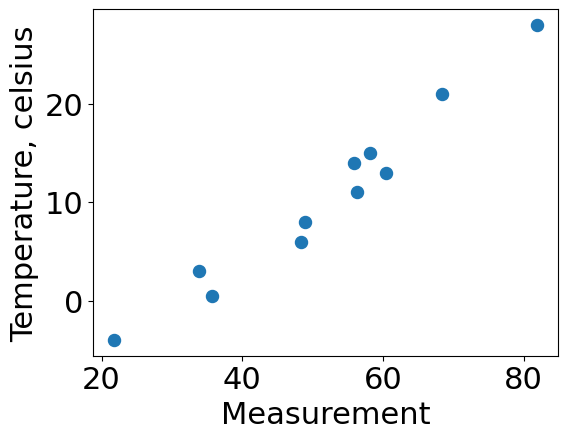

In [351]:
plt.figure(figsize=(6,4.5))
plt.scatter(to_numpy(t_u), to_numpy(t_c), s=75)
plt.xlabel('Measurement', fontsize=22)
plt.ylabel('Temperature, celsius', fontsize=22)
plt.gca().tick_params(axis='x', labelsize=22)
plt.gca().tick_params(axis='y', labelsize=22)

## Model Specification
It appears, that there's a linear relationship between the *measurement* and the true value of the ```temperature```


### Model
$$\large t_c = \textbf {w} \times t_u + \textbf {b}$$

| Parameter | Description |
|-----------|-------------|
| $w$ | *weight* |
| $b$ | *bias* |


## Loss Function Definition

<p style="font-size:30px">Loss Function:</p>
<p><i>Loss (or cost) Function</i> is used to characterize the fit of the model for the current set of parameters and input.</p>
<p><i>Loss Function</i> is an estimate of an error</p>

<p>The primary goal of any <i>optimization</i> is to find the set of parameters that minimize the <i>loss function</i> for the given input.</p>

### Loss function requirements:
- **Scalar** - must return single numerical value
- **Non-negative**

### Primary Loss function candidates:

| Function | Mathematical Form |
|----------|-------------------|
| Absolute error | $\|t_p - t_c\|$ |
| Squared error | $(t_p - t_c)^{2}$ |

**Where:**
- $t_c$ is the true value
- $t_p$ is the value predicted by the model: $t_p=w \cdot t_u + b$

**Properties:**
- Both functions have minimum value of 0
- Both are monotonic: they grow larger as the difference between the true and the predicted values grows


## Explore loss function behavior

In [352]:
def loss_function_1(y, y_tag):
    import numpy as np
    return np.abs(y-y_tag)

def loss_function_2(y, y_tag):
    import numpy as np
    return np.square(y-y_tag)

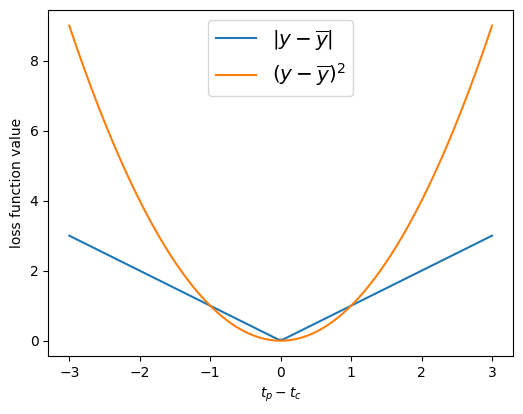

In [353]:
plt.figure(figsize=(6,4.5))
y_tag = np.linspace(-3,3, 100)
plt.plot(y_tag, loss_function_1(0, y_tag), label='$|y - \overline {y}|$')
plt.plot(y_tag, loss_function_2(0, y_tag), label='$(y - \overline {y})^2$')
plt.legend(fontsize ='x-large')
plt.xlabel('$t_p-t_c$'); plt.ylabel('loss function value');

<p>For the 2nd function: many slightly wrong results is better than few wildly wrong results</p>
<p>The 1st function doesn't care whether there's a single wildly wrong prediction or many small errors</p>
<br><br>

### Loss function derivative

<p>Plot of the loss function derivative (below) shows that <br>
sensitivity (penalty for a unit of error) of the loss function may depend on the size of error.</p> 

In [354]:
x = np.linspace(0,5,6)
x, np.diff(x)/1

(array([0., 1., 2., 3., 4., 5.]), array([1., 1., 1., 1., 1.]))

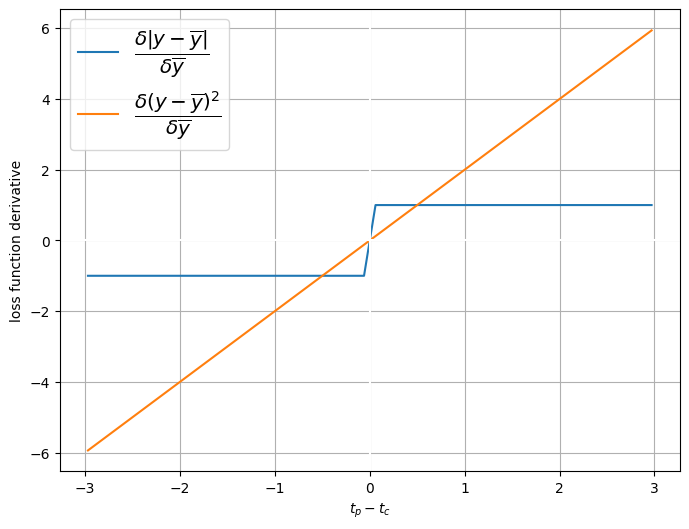

In [355]:
plt.figure(figsize=(8,6))
y_tag = np.linspace(-3,3, 100)

plt.plot(y_tag[:-1]+np.diff(y_tag)/2, np.diff(loss_function_1(0, y_tag))/np.diff(y_tag), 
             label='$\dfrac {\delta |y - \overline {y}|} {\delta \overline {y}}$')
plt.plot(y_tag[:-1]+np.diff(y_tag)/2, np.diff(loss_function_2(0, y_tag))/np.diff(y_tag), 
         label='$\dfrac {\delta (y - \overline {y})^2} {\delta \overline {y}} $')

plt.axhline(0, color='white')
plt.axvline(0, color='white')

plt.legend(fontsize ='x-large')
plt.xlabel('$t_p-t_c$'); plt.ylabel('loss function derivative');
plt.grid()

## Define the model and the loss

### Implement the model
Let's assume linear relationship between $t_u$ and $t_c$
$$\huge t_c = \textbf {w} \times t_u + \textbf {b} + \epsilon$$
$t_p$ - predicted value
$$\huge t_p = \textbf {w} \times t_u + \textbf {b}$$


In [356]:
def model(t_u, w, b): # note that t_u could be a vector. 
    return w* t_u + b

### Implement the loss function
mean sequare loss (cost function)

$$\large loss(p, t) = \frac {1}{N} \sum_{i=1}^{N}{(p_i-t_i)^2}$$


In [357]:
def loss_fn(t_p, t_c): # note that t_p & t_u could be vectors
    return torch.mean( (t_p-t_c)**2) # mean of element-wise squares of differences

## Complete  enumeration - implementation
- Systematically consider all possible solutions  
- Choose the best solution after considering all possible solutions
<p style="font-size:25px"><br>In our case:</p>
- Compute loss function for many values for the weight $w$ and bias $b$
- Find the set $(w, b)$ with the minimal value of loss. 

In [358]:
def model(t_u, w, b): 
    return w* t_u + b

In [359]:
def loss_fn(t_p, t_c): 
    return torch.mean( (t_p-t_c)**2, dim=0 ) # mean of element-wise squares of differences

### Define parameter space to search

In [360]:
w = torch.linspace(0.01, 5, 50, device=COMPUTE_DEVICE)      # resolution: 0.1
b = torch.linspace(-100, 100, 101, device=COMPUTE_DEVICE)   # resolution: 1
print(f"w device: {w.device}, b device: {b.device}")

w device: cpu, b device: cpu


### create all possible pairs of $(w,b)$ to test

In [361]:
w,b = torch.meshgrid(w,b, indexing='ij')
(w.shape, b.shape)

(torch.Size([50, 101]), torch.Size([50, 101]))

In [362]:
w

tensor([[0.0100, 0.0100, 0.0100,  ..., 0.0100, 0.0100, 0.0100],
        [0.1118, 0.1118, 0.1118,  ..., 0.1118, 0.1118, 0.1118],
        [0.2137, 0.2137, 0.2137,  ..., 0.2137, 0.2137, 0.2137],
        ...,
        [4.7963, 4.7963, 4.7963,  ..., 4.7963, 4.7963, 4.7963],
        [4.8982, 4.8982, 4.8982,  ..., 4.8982, 4.8982, 4.8982],
        [5.0000, 5.0000, 5.0000,  ..., 5.0000, 5.0000, 5.0000]])

In [363]:
b

tensor([[-100.,  -98.,  -96.,  ...,   96.,   98.,  100.],
        [-100.,  -98.,  -96.,  ...,   96.,   98.,  100.],
        [-100.,  -98.,  -96.,  ...,   96.,   98.,  100.],
        ...,
        [-100.,  -98.,  -96.,  ...,   96.,   98.,  100.],
        [-100.,  -98.,  -96.,  ...,   96.,   98.,  100.],
        [-100.,  -98.,  -96.,  ...,   96.,   98.,  100.]])

### Demonstrate parameter scape

Text(0.5, 1.0, 'Parameter space')

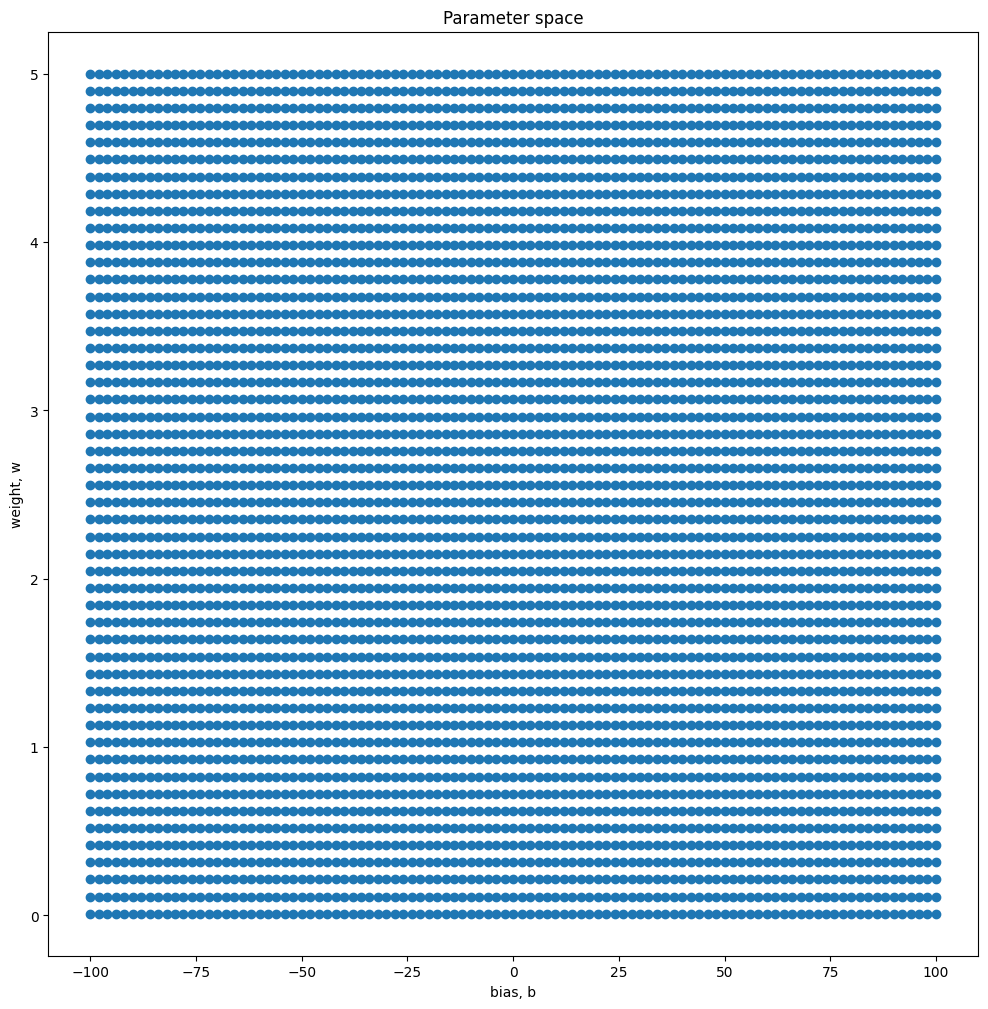

In [364]:
plt.figure(figsize=(12,12))
plt.scatter(to_numpy(b), to_numpy(w))
plt.xlabel('bias, b')
plt.ylabel('weight, w')
plt.title('Parameter space')

### Compute loss for every pair of $b$ and $w$

In [365]:
print(t_u.shape)

print(t_u.unsqueeze(-1).unsqueeze(-1).shape, w.shape, b.shape)
(((t_u.unsqueeze(-1).unsqueeze(-1)*w+b)-t_c.unsqueeze(-1).unsqueeze(-1))**2).mean(0).shape

torch.Size([11])
torch.Size([11, 1, 1]) torch.Size([50, 101]) torch.Size([50, 101])


torch.Size([50, 101])

In [366]:
t_p = model(t_u.unsqueeze(-1).unsqueeze(-1), w, b ) # model will use broadcast to compute t_p
print(f"t_u shape: {t_u.unsqueeze(-1).unsqueeze(-1).shape}. w shape: {w.shape}, b shape: {b.shape}")
print(f"t_p shape: {t_p.shape}")
loss_values = loss_fn(t_p, t_c.unsqueeze(-1).unsqueeze(-1))
print(f"loss_values shape: {loss_values.shape}")

t_u shape: torch.Size([11, 1, 1]). w shape: torch.Size([50, 101]), b shape: torch.Size([50, 101])
t_p shape: torch.Size([11, 50, 101])
loss_values shape: torch.Size([50, 101])


### Explore the parameter space

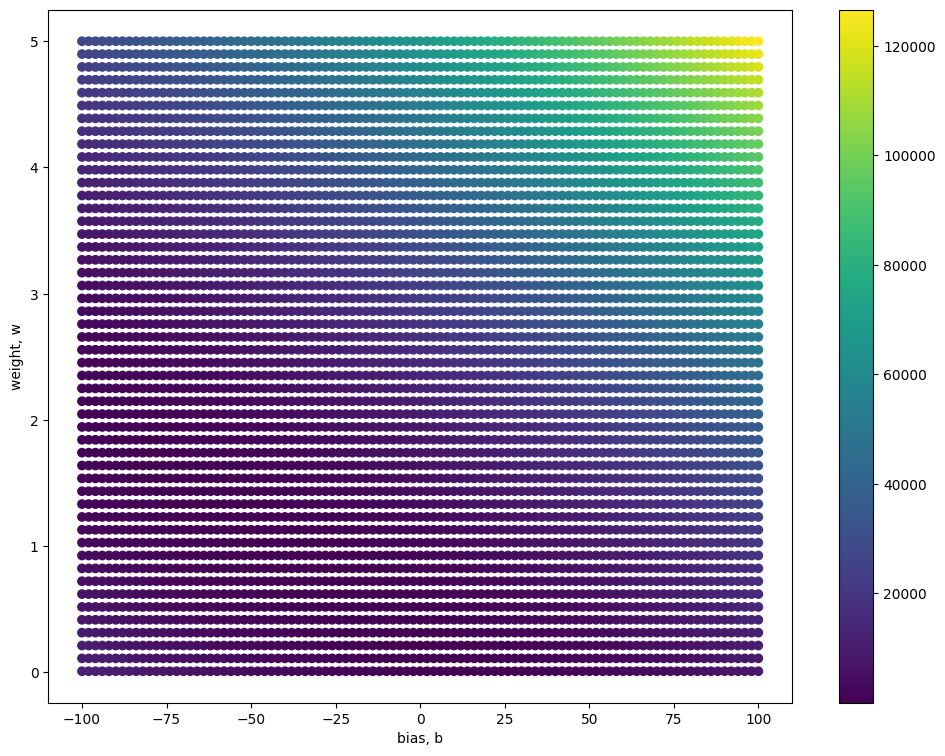

In [367]:
plt.figure(figsize=(12,9))
#plt.pcolor(to_numpy(b), to_numpy(w), to_numpy(loss_values), shading='nearest')
plt.scatter(to_numpy(b), to_numpy(w), c=to_numpy(loss_values))
plt.xlabel('bias, b')
plt.ylabel('weight, w')
plt.colorbar()

Too difficult to observe the loss function minima <br>
Let's try a different visualization technique

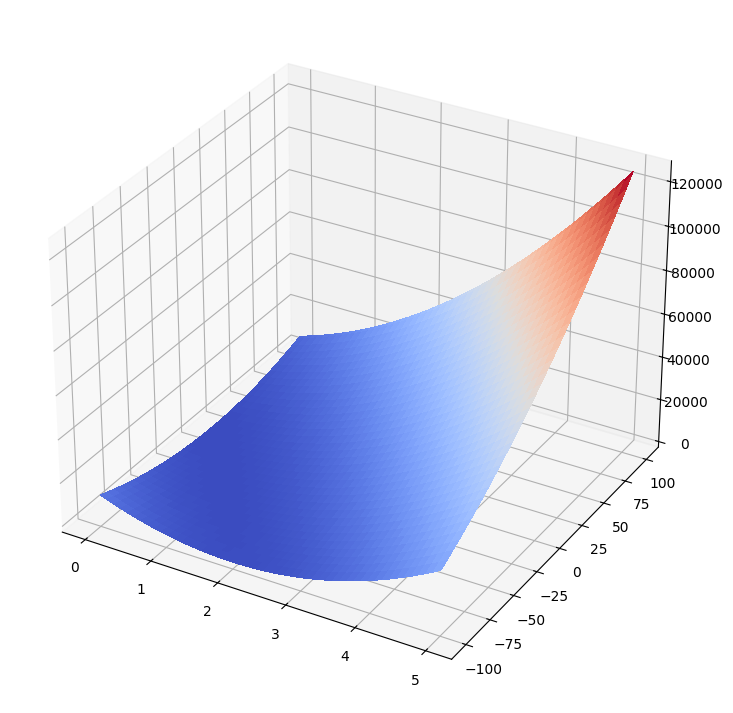

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(projection='3d')
# ax.view_init(elev=30, azim=30)  # uncomment to 'play' with rotations.
surf = ax.plot_surface(
    to_numpy(w),
    to_numpy(b),
    to_numpy(loss_values),
    cmap=cm.coolwarm,
    antialiased=False,
)


Apply $log$ to the loss for better visualization

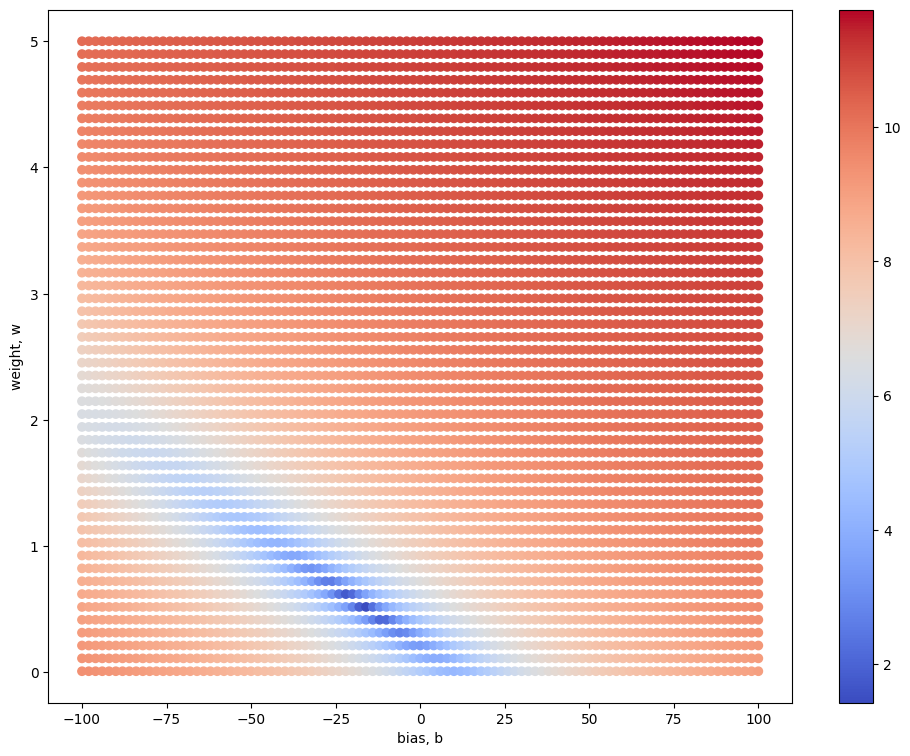

In [369]:
from matplotlib import cm  # colormap!
plt.figure(figsize=(12,9))
plt.scatter(to_numpy(b), to_numpy(w), c=to_numpy((loss_values + 1).log()), cmap=cm.coolwarm)
plt.xlabel('bias, b')
plt.ylabel('weight, w')
plt.colorbar()

Text(0.5, 0, 'loss')

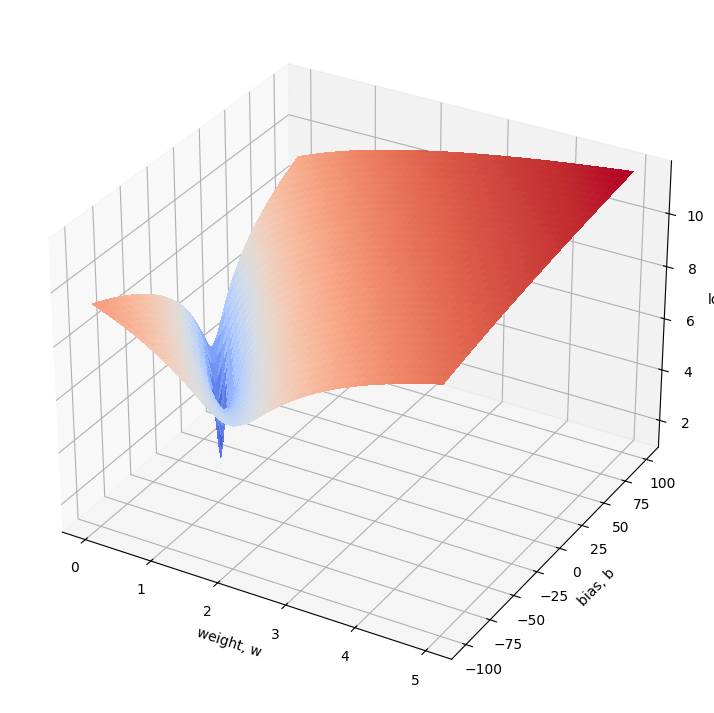

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(projection='3d')
# ax.view_init(elev=30, azim=150)  # uncomment to 'play' with rotations.
surf = ax.plot_surface(
    to_numpy(w),
    to_numpy(b),
    to_numpy(loss_values.log()),
    cmap=cm.coolwarm,
    antialiased=False,
)
ax.set_xlabel('weight, w')
ax.set_ylabel('bias, b')
ax.set_zlabel('loss')

Find $w$ & $b$ corresponding to the minimal value of the loss function. 

### Find  $(b,w)$ that minimize the loss

In [371]:
w.shape

torch.Size([50, 101])

In [372]:
loss_values.argmin()

tensor(547)

In [373]:
index_of_min_value = loss_values.argmin() # index of the loss minima. 

loss_function_minima = loss_values.flatten()[loss_values.argmin()]
w_loss_min = w.flatten()[loss_values.argmin()]
b_loss_min = b.flatten()[loss_values.argmin()]

print(f"minimal loss: {loss_function_minima:0.2f}")
print(f"weight: {w_loss_min:0.3f}")
print(f"bias: {b_loss_min:0.3f}")
print(f"mean error: { (t_c - model(t_u, w_loss_min, b_loss_min)).mean()}")

minimal loss: 3.16
weight: 0.519
bias: -16.000
mean error: -0.393716037273407


Note that the correct formula is:

$$
T_{celsius} = \frac{5}{9}\left(T_{fahrenheit} - 32\right)
$$

or

$$
T_{celsius} = 0.5556\,T_{fahrenheit} - 17.7778
$$

## Improve precision by refining the grid
The following cell contains complete code with higher-resolution grid

In [374]:
# establish a dataset
# This high-resolution full-enumeration section is memory-heavy.
# It is intentionally kept on CPU for stability across Mac and Windows.
HIGH_RES_DEVICE = torch.device("cpu")

t_c = torch.tensor(
    [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0],
    dtype=torch.float32,
    device=HIGH_RES_DEVICE,
)
t_u = torch.tensor(
    [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4],
    dtype=torch.float32,
    device=HIGH_RES_DEVICE,
)

def model(t_u, w, b):
    return w * t_u + b

def loss_fn(t_p, t_c):
    return torch.mean((t_p - t_c) ** 2, dim=0)  # mean of element-wise squares of differences

print(f"High-resolution section runs on: {HIGH_RES_DEVICE}")

w = torch.linspace(0.01, 5, 5000, device=HIGH_RES_DEVICE)      # resolution: 0.001
b = torch.linspace(-100, 100, 10001, device=HIGH_RES_DEVICE)   # resolution: 0.02
w, b = torch.meshgrid(w, b, indexing='ij')

t_p = model(t_u.unsqueeze(-1).unsqueeze(-1), w, b)  # model will use broadcast to compute t_p
loss_values = loss_fn(t_p, t_c.unsqueeze(-1).unsqueeze(-1))

print(f"minimal loss: {loss_values.flatten()[loss_values.argmin()]:0.2f}")
print(f"weight: {w.flatten()[loss_values.argmin()]:0.3f}")
print(f"bias: {b.flatten()[loss_values.argmin()]:0.3f}")
print(f"mean error: {(t_c - model(t_u, w.flatten()[loss_values.argmin()], b.flatten()[loss_values.argmin()])).mean():0.3f}")
print(f"mean squared error: {torch.mean(torch.square(t_c - model(t_u, w.flatten()[loss_values.argmin()], b.flatten()[loss_values.argmin()]))):0.3f}")

High-resolution section runs on: cpu
minimal loss: 2.93
weight: 0.537
bias: -17.320
mean error: 0.001
mean squared error: 2.928


## Complete Enumeration - scipy.optimize.fmin
https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.fmin.html

Similar to full enumeration technique, fmin uses function value only (not derivatives)<br>
It performs very badly for high-dimensions

In [375]:
import scipy.optimize
import numpy as np

t_c = np.array([0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0])
t_u = np.array([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4])

def loss_function(params, t_u, t_c):
    import numpy as np
    w,b = params
    return np.mean(np.square(t_u*w+b-t_c))

w0, b0 = -5, 100 # initial guess
result = scipy.optimize.fmin(func = loss_function, x0 = (w0,b0), args = (t_u, t_c),
                    maxfun=400, maxiter=400, ftol=1e-9, xtol=1e-9 )
print(result)

Optimization terminated successfully.
         Current function value: 2.927646
         Iterations: 98
         Function evaluations: 200
[  0.53677192 -17.30478551]


In [376]:
import scipy.optimize
import numpy as np

t_c = np.array([0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0])
t_u = np.array([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4])

def loss_function(params, t_u, t_c):
    import numpy as np
    w,b = params
    return np.mean(np.abs(t_u*w+b-t_c))

w0, b0 = 1, 0 # initial guess
result = scipy.optimize.fmin(func = loss_function, x0 = (w0,b0), args = (t_u, t_c),
                    maxfun=400, maxiter=400, ftol=1e-9, xtol=1e-9 )
print(result)

Optimization terminated successfully.
         Current function value: 1.528002
         Iterations: 171
         Function evaluations: 330
[  0.54852321 -16.92405063]


In [377]:
print(f"mean error: { (t_c - model(t_u, w=result[0], b=result[1])).mean():0.3e}")
print(f"mean square error: { np.mean(np.square(t_c - model(t_u, w=result[0], b=result[1]))):0.3f}")

mean error: -9.895e-01
mean square error: 3.942
